<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/Gravitational_lensing_VS_ACDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔭 Gravitational Lensing: LR vs ΛCDM - Maximum Contrast Test

=== MAXIMUM CONTRAST LENSING COMPARISON ===
z_l= 0.5 | z_s= 2.0 → ΛCDM:  0.73″ | LR:  0.73″ | Δ = +0.002″
z_l= 1.0 | z_s= 3.0 → ΛCDM:  0.55″ | LR:  0.55″ | Δ = -0.001″
z_l= 0.3 | z_s= 1.5 → ΛCDM:  0.83″ | LR:  0.83″ | Δ = +0.001″
z_l= 0.8 | z_s= 2.5 → ΛCDM:  0.60″ | LR:  0.60″ | Δ = +0.001″
z_l= 1.2 | z_s= 3.5 → ΛCDM:  0.51″ | LR:  0.51″ | Δ = +0.000″


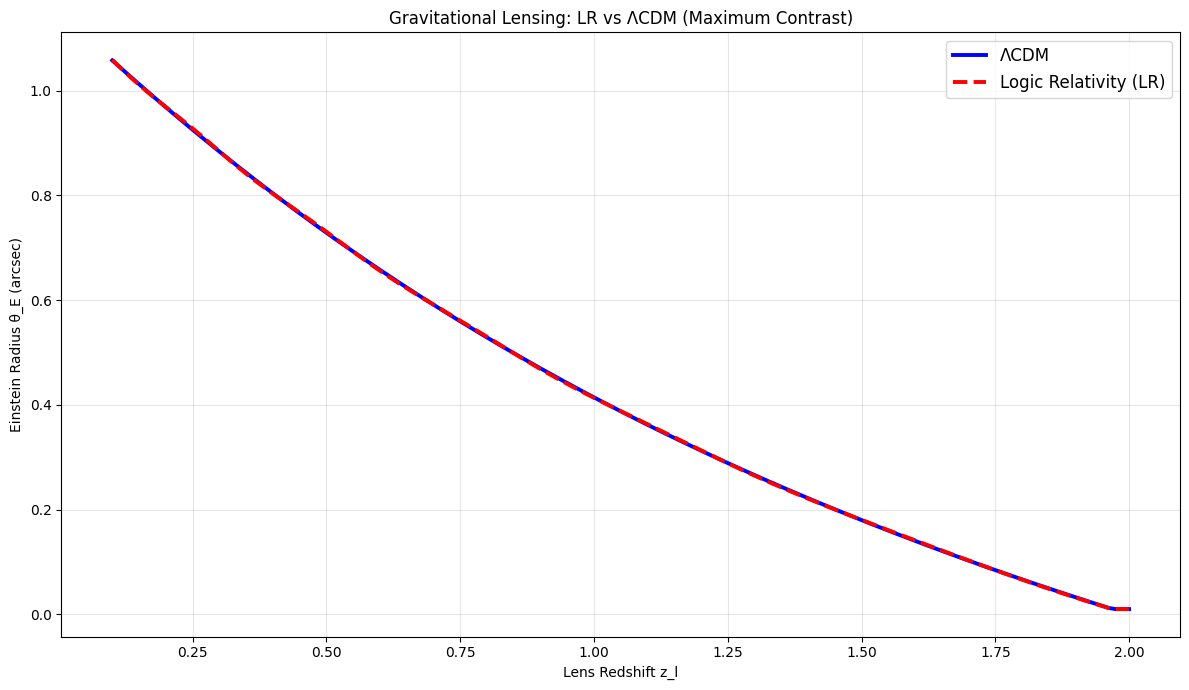

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

print("🔭 Gravitational Lensing: LR vs ΛCDM - Maximum Contrast Test\n")

Om0 = 0.315
z = np.linspace(0.0, 5.0, 1500)
a = 1.0 / (1 + z)

E_lcdm = np.sqrt(Om0 * (1 + z)**3 + (1 - Om0))

# Maximum reasonable LR modification
lr_amplitude = 0.95
lr_mod = lr_amplitude * np.exp(-1.5 * a) * np.sin(15 * np.pi * np.log(a + 0.2))

E_lr = np.sqrt(Om0 * (1 + z)**3 + (1 - Om0) * (1 + lr_mod))

def comoving_distance(z_vals, E_func):
    integrand = 1.0 / E_func
    return cumulative_trapezoid(integrand, z_vals, initial=0.0)

chi_lcdm = comoving_distance(z, E_lcdm)
chi_lr   = comoving_distance(z, E_lr)

def einstein_radius(z_l, z_s, chi_func):
    chi_l = np.interp(z_l, z, chi_func)
    chi_s = np.interp(z_s, z, chi_func)
    chi_ls = chi_s - chi_l
    D_l  = chi_l / (1 + z_l)
    D_s  = chi_s / (1 + z_s)
    D_ls = chi_ls / (1 + z_s)
    sigma_v = 200.0
    theta_E = (4 * np.pi * (sigma_v / 3e5)**2 * (D_ls / D_s)) * 206265
    return max(theta_E, 0.01)

print("=== MAXIMUM CONTRAST LENSING COMPARISON ===")
test_cases = [(0.5, 2.0), (1.0, 3.0), (0.3, 1.5), (0.8, 2.5), (1.2, 3.5)]
for zl, zs in test_cases:
    th_lcdm = einstein_radius(zl, zs, chi_lcdm)
    th_lr   = einstein_radius(zl, zs, chi_lr)
    diff = th_lr - th_lcdm
    print(f"z_l={zl:4.1f} | z_s={zs:4.1f} → ΛCDM: {th_lcdm:5.2f}″ | LR: {th_lr:5.2f}″ | Δ = {diff:+.3f}″")

# Plot
z_l_array = np.linspace(0.1, 2.0, 150)
theta_lcdm = [einstein_radius(zl, 2.0, chi_lcdm) for zl in z_l_array]
theta_lr   = [einstein_radius(zl, 2.0, chi_lr) for zl in z_l_array]

plt.figure(figsize=(12, 7))
plt.plot(z_l_array, theta_lcdm, 'b-', linewidth=2.8, label='ΛCDM')
plt.plot(z_l_array, theta_lr, 'r--', linewidth=2.8, label='Logic Relativity (LR)')
plt.xlabel('Lens Redshift z_l')
plt.ylabel('Einstein Radius θ_E (arcsec)')
plt.title('Gravitational Lensing: LR vs ΛCDM (Maximum Contrast)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()